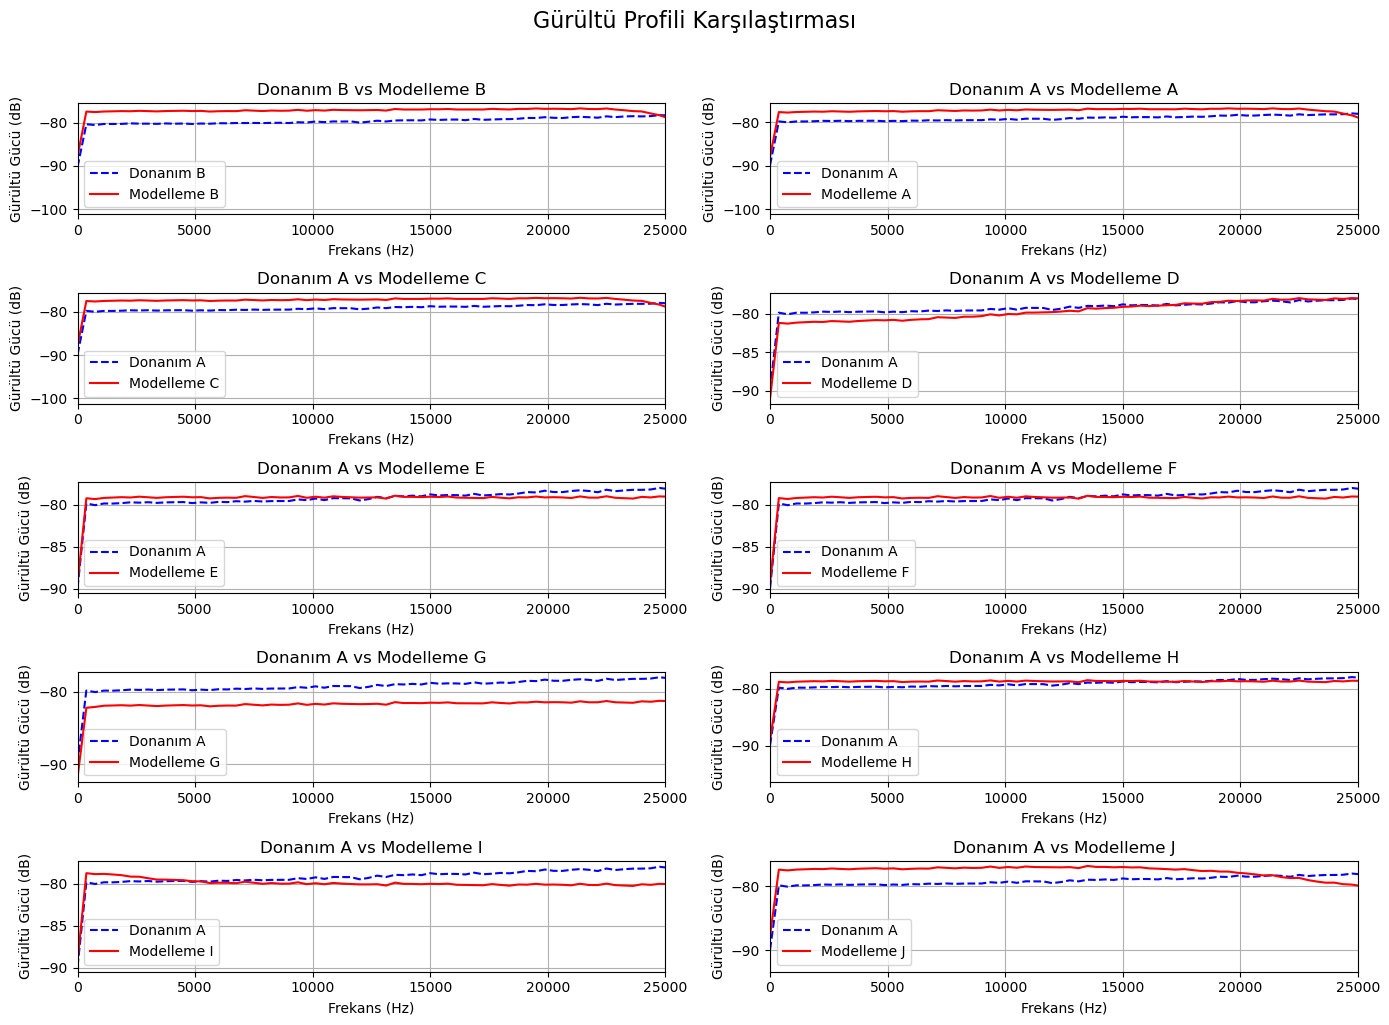

In [16]:
# Ses sinyallerinin frekans bazlı gürültü profillerini karşılaştırmak için hazırlanmıştır.
# Y ekseni, her bir frekanstaki ortalama gürültü gücünü (power) ifade eder.
# Bu değerler logaritmik ölçekte dB (desibel) cinsinden gösterilir.
# White noise, tüm frekanslara eşit enerji dağıttığından frekansa duyarlı işleme özellikleri analiz etmek için ideal bir sinyaldir.
# LA-2A'nın kompresör etkisinin her frekans bandında nasıl çalıştığını incelemek için uygundur.

# Librosa sisteminin aktarılması
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import pyloudnorm as pyln
import IPython.display as ipd
from IPython.display import Audio, display
from scipy import signal

# Ses dosyalarının yollarını bir listeye ekleme
audio_files = [
    "/Users/nazimerensahin/Desktop/processed/teletronix_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/urei_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_gray_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_silver_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_tube_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/waves_cla-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ikm_white-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ni_softube_vc-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ss_fg-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/bra_vla-2a_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/overloud_gem-comp-la_white_noise.wav",
    "/Users/nazimerensahin/Desktop/processed/ao_lala_white_noise.wav",
]

# Ses dosyalarının isimlendirilmesi
audio_labels = [
    "Donanım A",
    "Donanım B",
    "Modelleme A",
    "Modelleme B",
    "Modelleme C",
    "Modelleme D",
    "Modelleme E",
    "Modelleme F",
    "Modelleme G",
    "Modelleme H",
    "Modelleme I",
    "Modelleme J",
]

# Gürültü profili karşılaştırma fonksiyonu
def plot_noise_profiles(reference_signals, reference_labels, comparison_signals, comparison_labels, sr):
    """
    Referans ses sinyali ile diğer ses dosyalarının gürültü profillerini iki sütunlu bir düzende karşılaştırır.
    """
    epsilon = 1e-10  # Sıfır bölünme hatasını önlemek için küçük bir değer

    n_comparisons = len(comparison_signals)
    n_cols = 2
    n_rows = (n_comparisons + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2))
    axes = axes.flatten()

    for i, (ref_signal, ref_label, comp_signal, comp_label) in enumerate(zip(reference_signals, reference_labels, comparison_signals, comparison_labels)):
        # Referans spektrumu hesapla
        freqs_ref, _, Sxx_ref = signal.spectrogram(ref_signal, sr)
        ref_power = np.mean(10 * np.log10(Sxx_ref + epsilon), axis=1)

        # Karşılaştırma spektrumu hesapla
        freqs, _, Sxx = signal.spectrogram(comp_signal, sr)
        comp_power = np.mean(10 * np.log10(Sxx + epsilon), axis=1)

        ax = axes[i]
        ax.plot(freqs_ref, ref_power, label=ref_label, linestyle="--", color="blue")
        ax.plot(freqs, comp_power, label=comp_label, color="red")
        ax.set_title(f"{ref_label} vs {comp_label}")
        ax.set_xlabel("Frekans (Hz)")
        ax.set_ylabel("Gürültü Gücü (dB)")
        ax.set_xlim(0, 25000)
        ax.legend()
        ax.grid()

    # Kullanılmayan eksenleri kaldır
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Gürültü Profili Karşılaştırması", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Ses dosyalarını yükleme
audio_signals = [librosa.load(file, sr=None) for file in audio_files]
signals, sample_rates = zip(*audio_signals)

# Karşılaştırmalar:
reference_signals = [
    signals[1],  # Urei LA-2A
    *([signals[0]] * 9),  # Teletronix LA-2A
]
reference_labels = [
    "Donanım B",
    *([audio_labels[0]] * 9),
]
comparison_signals = [
    signals[3],  # UAD LA-2A Silver
    *[signals[i] for i in range(len(audio_files)) if i not in {0, 1, 3}],  # Teletronix comparisons
]
comparison_labels = [
    "Modelleme B",
    *[audio_labels[i] for i in range(len(audio_files)) if i not in {0, 1, 3}],
]

# Gürültü profillerini çiz
plot_noise_profiles(reference_signals, reference_labels, comparison_signals, comparison_labels, sr=sample_rates[0])
